Memuat dataset final...
Total data : 2274
Data Human : 1137
Data AI    : 1137
Balance    : Seimbang

Mengekstrak fitur linguistik dari dataset...

Hasil uji statistik fitur linguistik (Mann-Whitney U):
Fitur                                    Human         AI      U-value      p-value      Sig  r-value Keterangan
-------------------------------------------------------------------------------------------------------------------
Jumlah Kata                            98.6218    84.8980    1047230.5     0.000000       Ya    0.620   Efek Besar
Rata-rata Panjang Kalimat              20.3983    29.4421     316916.0     0.000000       Ya    0.510   Efek Besar
Variasi Panjang Kalimat                 7.9877    15.4454     261758.5     0.000000       Ya    0.595   Efek Besar
Jumlah Kalimat                          5.3069     3.3527    1079522.0     0.000000       Ya    0.670   Efek Besar
Rasio Koma                              0.0359     0.0822     209865.5     0.000000       Ya    0.675   Efek 

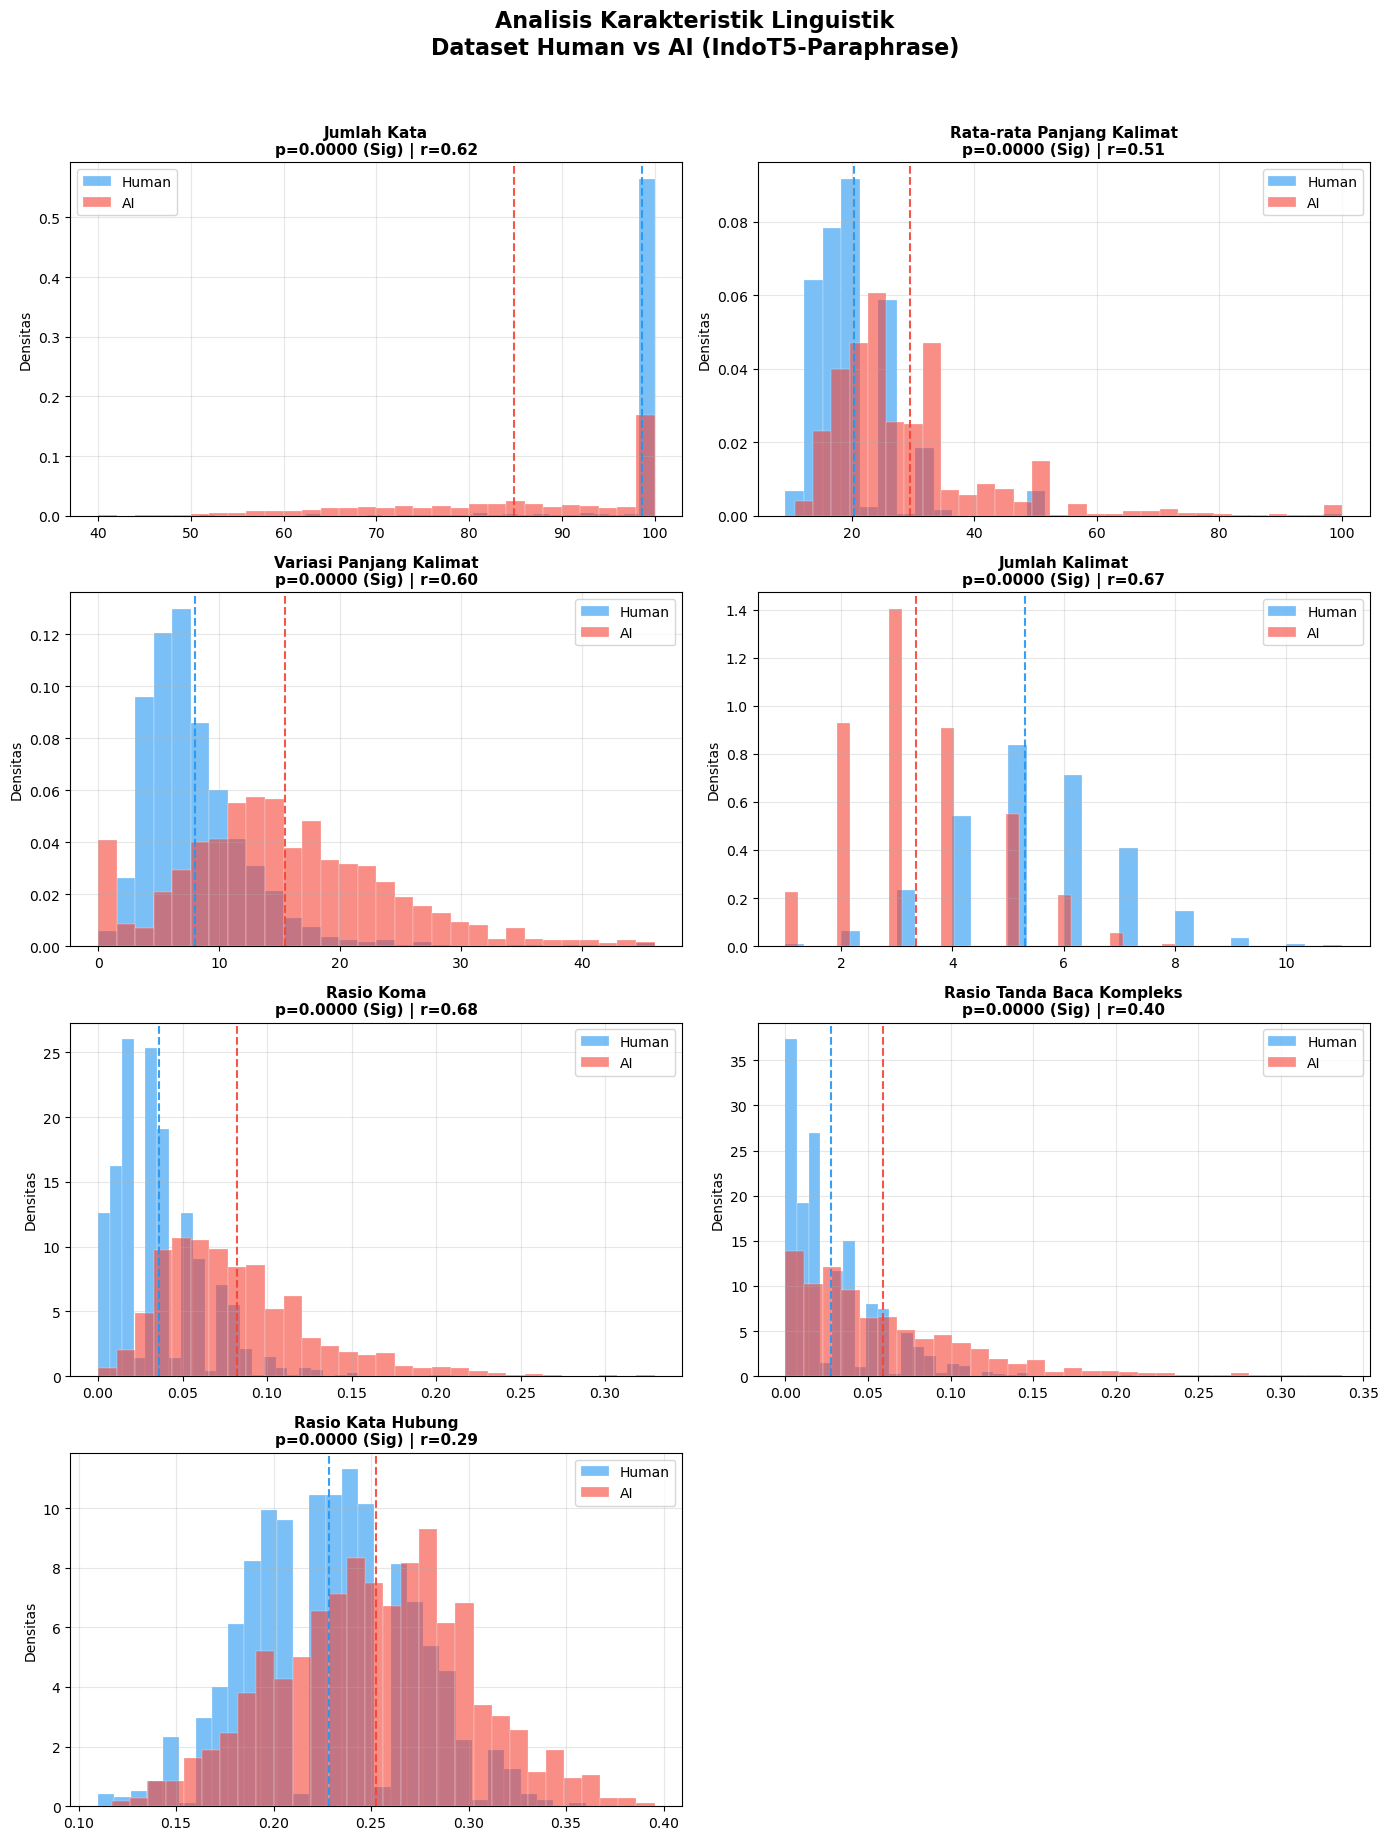


Menampilkan boxplot perbandingan fitur kunci...


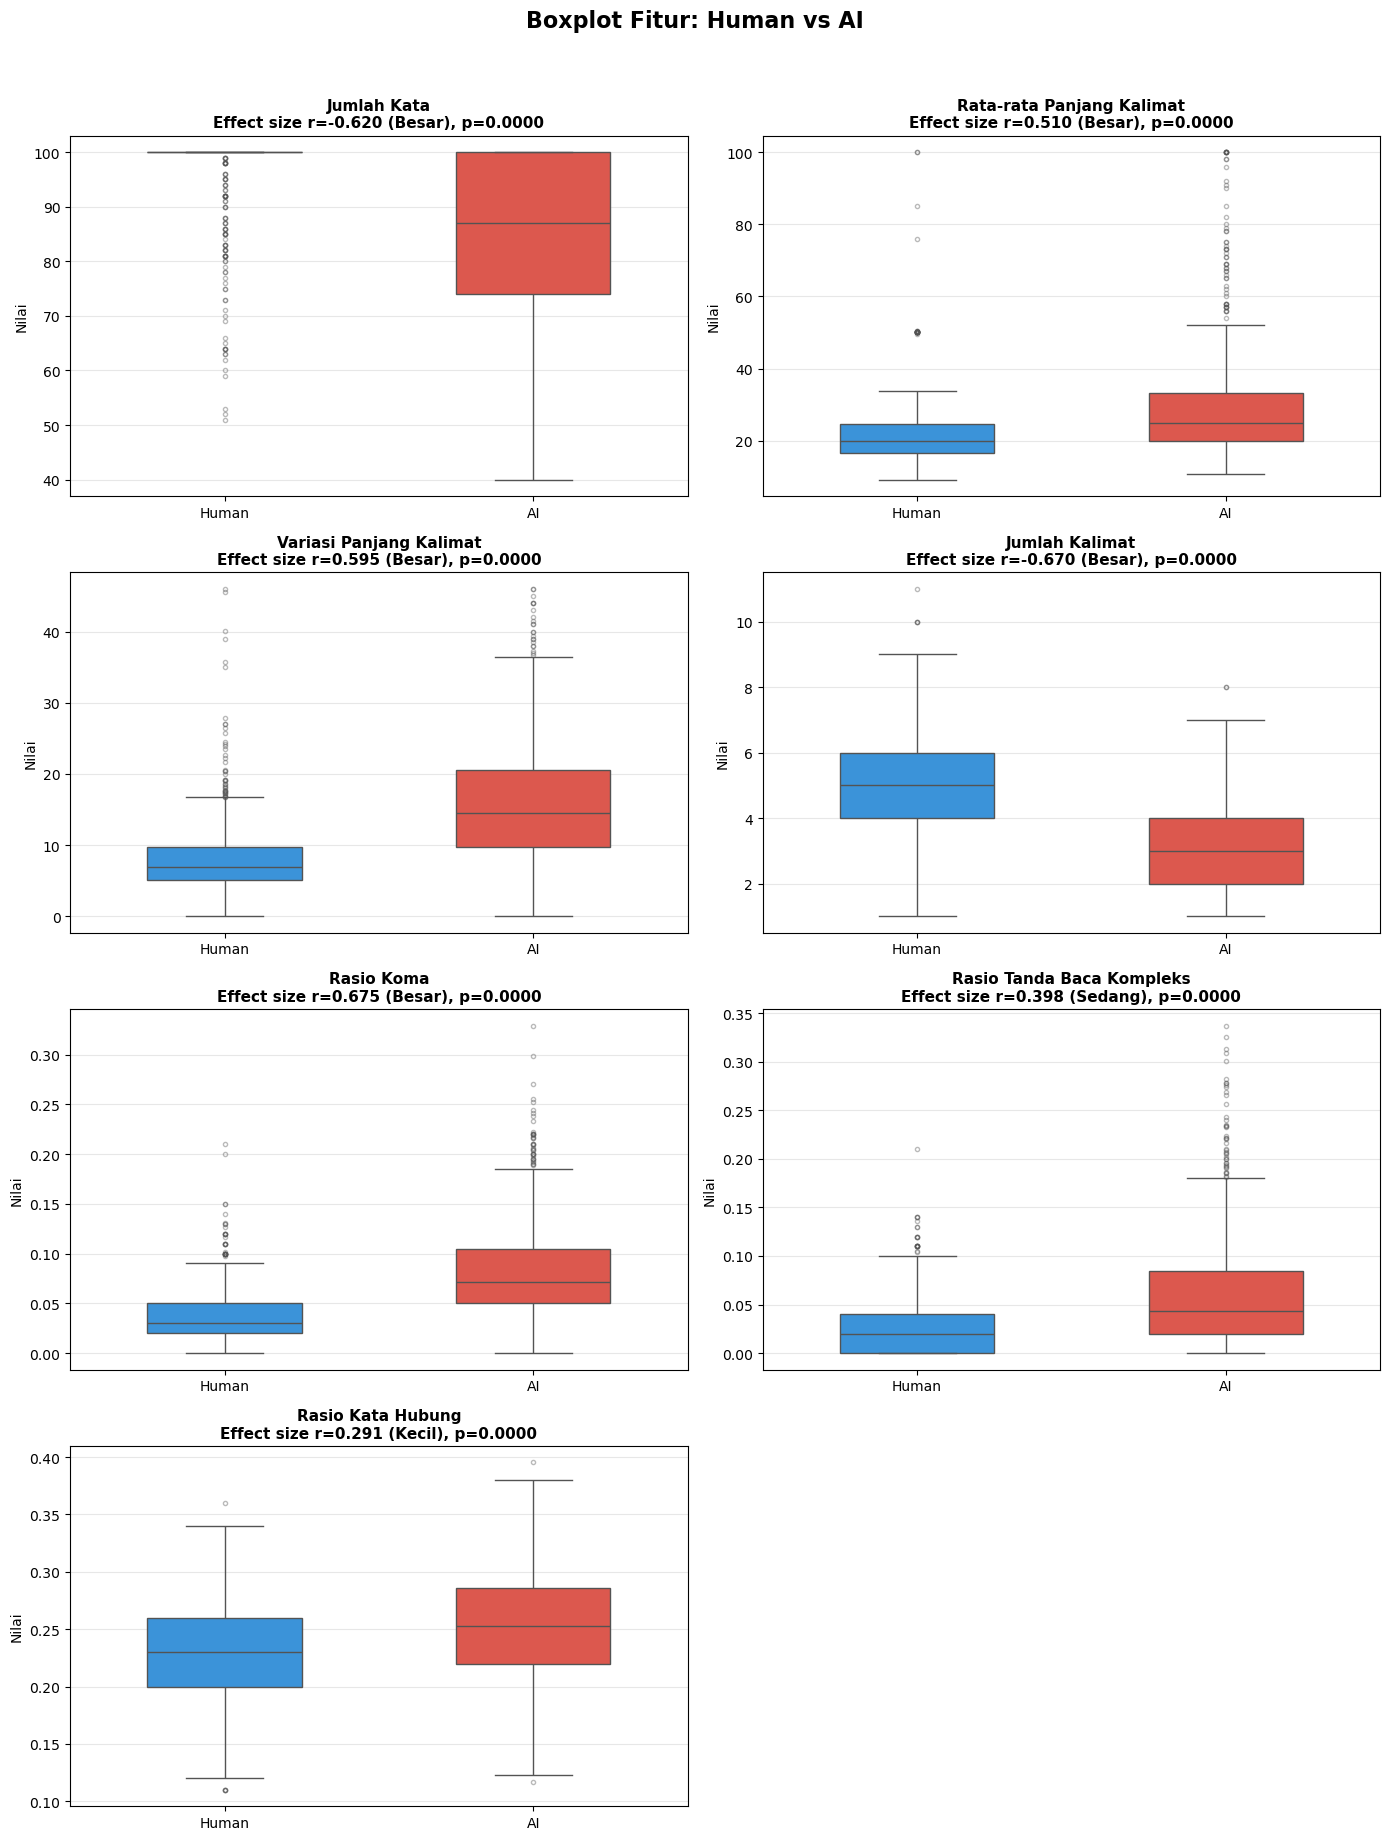


Proses analisis karakteristik dataset selesai.


In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Memuat dataset
df = pd.read_csv('../data/processed/final_dataset_detector_v1_12_fix.csv')
human_texts = df[df['label'] == 'human']['abstract'].tolist()
ai_texts    = df[df['label'] == 'ai']['abstract'].tolist()

print("Memuat dataset final...")
print(f"Total data : {len(df)}")
print(f"Data Human : {len(human_texts)}")
print(f"Data AI    : {len(ai_texts)}")
print(f"Balance    : {'Seimbang' if len(human_texts) == len(ai_texts) else 'Tidak Seimbang'}")

# Ekstraksi fitur linguistik (sesuai landasan teori)
kata_fungsi = {
    'yang','dan','di','dengan','untuk','dari','pada','dalam','adalah',
    'ini','itu','ke','oleh','atau','juga','telah','akan','dapat',
    'sebagai','tidak','ada','sudah','serta','karena','namun','tetapi',
    'bahwa','sehingga','agar','ketika','jika','bila','maka','seperti'
}

def extract_features(text):
    text = str(text)
    words       = text.split()
    words_lower = text.lower().split()
    sentences   = [s.strip() for s in re.split(r'[.?!]', text) if len(s.strip().split()) >= 3]

    if not words:
        return {k: 0 for k in [
            'word_count','avg_sentence_length','std_sentence_length',
            'num_sentences','koma_ratio','punct_kompleks_ratio','func_word_ratio'
        ]}

    wc         = len(words)
    sent_lens = [len(s.split()) for s in sentences]
    avg_sl    = np.mean(sent_lens)    if sent_lens         else 0
    std_sl    = np.std(sent_lens)     if len(sent_lens) >= 2 else 0
    num_sent  = len(sentences)

    koma_ratio = len(re.findall(r'[,]', text)) / wc
    punct_kompleks_ratio = len(re.findall(r'[;:()\[\]-]', text)) / wc
    func_ratio  = sum(1 for w in words_lower if w in kata_fungsi) / wc

    return {
        'word_count'         : wc,
        'avg_sentence_length'  : avg_sl,
        'std_sentence_length'  : std_sl,
        'num_sentences'        : num_sent,
        'koma_ratio'         : koma_ratio,
        'punct_kompleks_ratio' : punct_kompleks_ratio,
        'func_word_ratio'      : func_ratio
    }

print("\nMengekstrak fitur linguistik dari dataset...")
h_feats = [extract_features(t) for t in human_texts]
a_feats = [extract_features(t) for t in ai_texts]

feat_names = list(h_feats[0].keys())
feat_labels = {
    'word_count'         : 'Jumlah Kata',
    'avg_sentence_length'  : 'Rata-rata Panjang Kalimat',
    'std_sentence_length'  : 'Variasi Panjang Kalimat',
    'num_sentences'        : 'Jumlah Kalimat',
    'koma_ratio'         : 'Rasio Koma',
    'punct_kompleks_ratio' : 'Rasio Tanda Baca Kompleks',
    'func_word_ratio'      : 'Rasio Kata Hubung',
}

# Uji statistik Mann-Whitney U
print("\nHasil uji statistik fitur linguistik (Mann-Whitney U):")
print(f"{'Fitur':<35} {'Human':>10} {'AI':>10} {'U-value':>12} {'p-value':>12} {'Sig':>8} {'r-value':>8} {'Keterangan'}")
print("-" * 115)

results = {}
for feat in feat_names:
    h_vals = np.array([x[feat] for x in h_feats])
    a_vals = np.array([x[feat] for x in a_feats])
    stat, p = stats.mannwhitneyu(h_vals, a_vals, alternative='two-sided')

    h_mean  = np.mean(h_vals)
    a_mean  = np.mean(a_vals)
    sig     = 'Ya' if p < 0.05 else 'Tidak'

    n1, n2   = len(h_vals), len(a_vals)
    r_effect = 1 - (2 * stat) / (n1 * n2)
    
    if   abs(r_effect) >= 0.5: ket = 'Efek Besar'
    elif abs(r_effect) >= 0.3: ket = 'Efek Sedang'
    elif abs(r_effect) >= 0.1: ket = 'Efek Kecil'
    else:                      ket = 'Efek Minimal'

    label = feat_labels.get(feat, feat)
    print(f"{label:<35} {h_mean:>10.4f} {a_mean:>10.4f} {stat:>12.1f} {p:>12.6f} {sig:>8} {abs(r_effect):>8.3f}   {ket}")

    results[feat] = {
        'h_vals' : h_vals, 'a_vals'   : a_vals,
        'h_mean' : h_mean, 'a_mean'   : a_mean,
        'stat'   : stat,   'p'        : p,      'r_effect' : r_effect
    }
print("-" * 115)

# Visualisasi distribusi fitur (Histogram)
print("\nMenampilkan visualisasi distribusi fitur...")
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('Analisis Karakteristik Linguistik\nDataset Human vs AI (IndoT5-Paraphrase)', fontsize=16, fontweight='bold', y=1.02)
colors = {'human': '#2196F3', 'ai': '#F44336'}

for idx, feat in enumerate(feat_names):
    ax  = axes[idx // 2][idx % 2]
    h_v = results[feat]['h_vals']
    a_v = results[feat]['a_vals']
    p   = results[feat]['p']
    r   = results[feat]['r_effect']

    ax.hist(h_v, bins=30, alpha=0.6, color=colors['human'], label='Human', density=True, edgecolor='white', linewidth=0.3)
    ax.hist(a_v, bins=30, alpha=0.6, color=colors['ai'], label='AI', density=True, edgecolor='white', linewidth=0.3)

    ax.axvline(results[feat]['h_mean'], color=colors['human'], linestyle='--', linewidth=1.5, alpha=0.9)
    ax.axvline(results[feat]['a_mean'], color=colors['ai'], linestyle='--', linewidth=1.5, alpha=0.9)

    sig_str = f"p={p:.4f} {'(Sig)' if p < 0.05 else '(Non-Sig)'} | r={abs(r):.2f}"
    ax.set_title(f"{feat_labels[feat]}\n{sig_str}", fontsize=11, fontweight='bold')
    ax.set_ylabel('Densitas', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

fig.delaxes(axes[3][1])
plt.tight_layout()
plt.show()

# Visualisasi Boxplot
print("\nMenampilkan boxplot perbandingan fitur kunci...")
fig, axes = plt.subplots(4, 2, figsize=(14, 18))
fig.suptitle('Boxplot Fitur: Human vs AI', fontsize=16, fontweight='bold', y=1.02)
key_feats = ['word_count', 'avg_sentence_length', 'std_sentence_length', 'num_sentences', 'koma_ratio', 'punct_kompleks_ratio', 'func_word_ratio']

for idx, feat in enumerate(key_feats):
    ax = axes[idx // 2][idx % 2]
    data_plot = pd.DataFrame({'Nilai' : np.concatenate([results[feat]['h_vals'], results[feat]['a_vals']]), 'Kelas' : ['Human'] * len(results[feat]['h_vals']) + ['AI'] * len(results[feat]['a_vals'])})
    sns.boxplot(data=data_plot, x='Kelas', y='Nilai', hue='Kelas', ax=ax, palette={'Human': '#2196F3', 'AI': '#F44336'}, width=0.5, flierprops=dict(markersize=3, alpha=0.4), legend=False)
    r = results[feat]['r_effect']
    p = results[feat]['p']
    eff = 'Besar' if abs(r) >= 0.5 else 'Sedang' if abs(r) >= 0.3 else 'Kecil'
    ax.set_title(f"{feat_labels[feat]}\nEffect size r={r:.3f} ({eff}), p={p:.4f}", fontsize=11, fontweight='bold')
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.3)

fig.delaxes(axes[3][1])
plt.tight_layout()
plt.show()

print("\nProses analisis karakteristik dataset selesai.")

Membuat visualisasi word cloud...


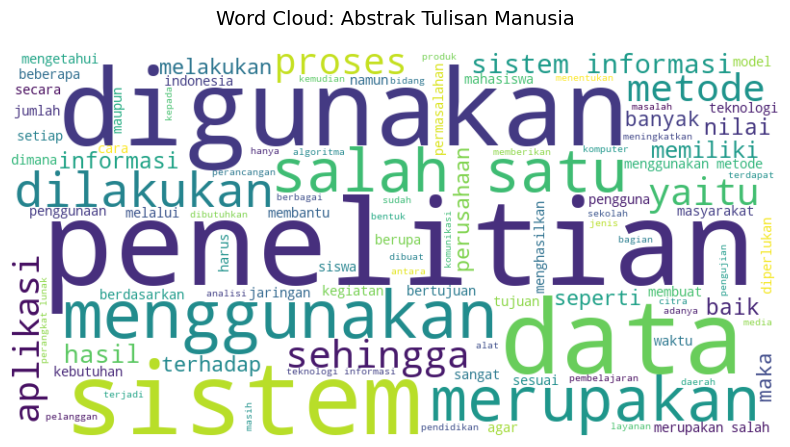

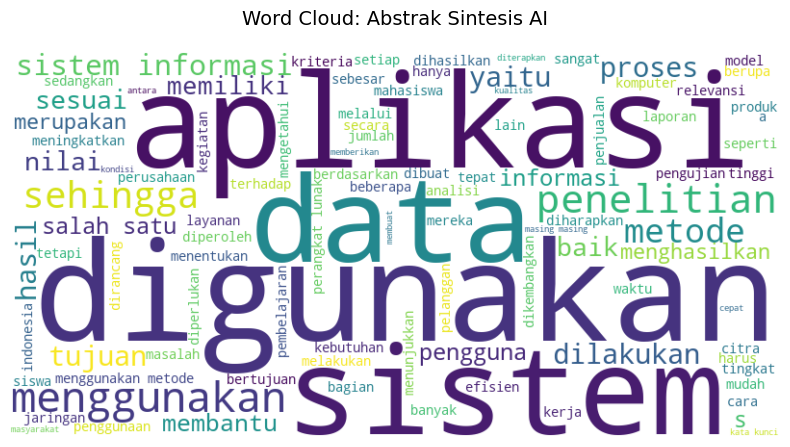

Top 20 kata paling sering muncul pada dataset AI:
- sistem          : 1264 kali
- data            : 836 kali
- menggunakan     : 834 kali
- aplikasi        : 714 kali
- digunakan       : 706 kali
- informasi       : 699 kali
- metode          : 628 kali
- penelitian      : 510 kali
- hasil           : 497 kali
- sehingga        : 407 kali
- proses          : 360 kali
- dilakukan       : 335 kali
- secara          : 306 kali
- nilai           : 303 kali
- tujuan          : 274 kali
- memiliki        : 266 kali
- yaitu           : 261 kali
- membantu        : 257 kali
- keputusan       : 247 kali
- satu            : 243 kali

Top 20 kata paling sering muncul pada dataset Manusia:
- sistem          : 1311 kali
- menggunakan     : 956 kali
- data            : 902 kali
- informasi       : 848 kali
- penelitian      : 826 kali
- metode          : 773 kali
- digunakan       : 608 kali
- merupakan       : 595 kali
- dilakukan       : 558 kali
- salah           : 510 kali
- proses          : 50

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# Daftar kata hubung untuk pembersihan visual
stop_words_indo = [
    "yang", "dan", "di", "dari", "ini", "dengan", "untuk", "pada", "adalah", 
    "itu", "dalam", "bahwa", "oleh", "ke", "sebagai", "tersebut", "tidak", 
    "akan", "bisa", "dapat", "ada", "juga", "karena", "kita", "saat", "menjadi",
    "sebuah", "suatu", "lebih", "telah", "hal", "serta", "atau"
]

# Memuat dataset
df = pd.read_csv('../data/processed/final_dataset_detector_v1_12_fix.csv')
df_human = df[df['label'] == 'human']['abstract']
df_ai = df[df['label'] == 'ai']['abstract']

# Fungsi pembuat visualisasi word cloud
def buat_wordcloud(text_series, title):
    text = " ".join(str(t) for t in text_series)
    wordcloud = WordCloud(
        width=800, height=400, background_color='white', 
        colormap='viridis', stopwords=stop_words_indo, max_words=100
    ).generate(text)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=14, pad=20)
    plt.axis('off')
    plt.show()

print("Membuat visualisasi word cloud...")
buat_wordcloud(df_human, "Word Cloud: Abstrak Tulisan Manusia")
buat_wordcloud(df_ai, "Word Cloud: Abstrak Sintesis AI")

# Ekstraksi dan rekapitulasi frekuensi kata
def get_top_words(text_series, n=20):
    vec = CountVectorizer(stop_words=stop_words_indo, max_features=n)
    fit = vec.fit_transform(text_series)
    freq = zip(vec.get_feature_names_out(), fit.toarray().sum(axis=0))
    return sorted(freq, key=lambda x: x[1], reverse=True)

# Menampilkan 20 kata paling sering muncul
kamus_ai = get_top_words(df_ai)
kamus_human = get_top_words(df_human)

print("Top 20 kata paling sering muncul pada dataset AI:")
for kata, freq in kamus_ai:
    print(f"- {kata:<15} : {freq} kali")

print("\nTop 20 kata paling sering muncul pada dataset Manusia:")
for kata, freq in kamus_human:
    print(f"- {kata:<15} : {freq} kali")